# 🎯 Feature Importance — Understanding Your Model

**Purpose:** Learn which features your model uses most to make predictions.

**What you'll learn:**
- What is feature importance?
- How to find the most important features
- How to visualize feature importance
- How to simplify your model by removing unimportant features
- How to use SHAP to explain individual predictions

---

## 💡 Why Should I Care About Feature Importance?

**Simple Answer:** Know which data actually matters!

**Example:**
```
You built a churn prediction model with 50 features.
Feature importance tells you:
  ✓ "usage_last_month" = 25% of predictions
  ✓ "complaints_count" = 15% of predictions  
  ✓ "shoe_size" = 0.01% of predictions  ← Remove this!
```

**Benefits:**
1. **Understand your model** - Know WHY it makes predictions
2. **Remove useless features** - Faster training, simpler model
3. **Explain to others** - "The top 3 reasons customers churn are..."
4. **Find problems** - If a weird feature is important, something's wrong!
5. **Build trust** - Show stakeholders exactly how decisions are made

## Import Libraries

In [2]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from catboost import Pool, CatBoostClassifier
import shap

# For reproducibility
SEED = 42
np.random.seed(SEED)

print("✓ Libraries imported")

✓ Libraries imported


/Users/federicodealbawork/miniconda3/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [3]:
# Target column
TARGET_COL = "churn"

# ID columns to drop (we don't want these in the model)
ID_COLS = ["idconsumo", "codigocontaservico", "idconta", "iddim_cliente", 
           "idcliente", "codigocliente", "iddim_conta", "codigoconta"]

# How many top features to show in plots
TOP_N = 20

print(f"✓ Configuration set")

✓ Configuration set


## 1. Load Data

Same data we've been using in previous notebooks.

In [4]:
# Load the cleaned data
DATA_DIR = "../2. Training/data_preparation_output"

train_df = pd.read_parquet(f"{DATA_DIR}/train.parquet")
val_df = pd.read_parquet(f"{DATA_DIR}/val.parquet")

print(f"✓ Data loaded:")
print(f"  Train: {len(train_df):,} rows")
print(f"  Val:   {len(val_df):,} rows")

✓ Data loaded:
  Train: 82,717 rows
  Val:   10,340 rows


## 2. Prepare Features

Same preprocessing as before: drop IDs and dates, separate X and y.

In [5]:
# Drop ID columns (we don't need these)
for col in ID_COLS:
    if col in train_df.columns:
        train_df = train_df.drop(columns=[col])
        val_df = val_df.drop(columns=[col])

# Drop ALL date/datetime columns (CatBoost can't handle NaT values)
date_cols_to_drop = []
for col in train_df.columns:
    if pd.api.types.is_datetime64_any_dtype(train_df[col]):
        date_cols_to_drop.append(col)

if len(date_cols_to_drop) > 0:
    print(f"Dropping {len(date_cols_to_drop)} date columns: {date_cols_to_drop}")
    train_df = train_df.drop(columns=date_cols_to_drop)
    val_df = val_df.drop(columns=date_cols_to_drop)

# Separate X (features) and y (target)
y_train = train_df[TARGET_COL]
X_train = train_df.drop(columns=[TARGET_COL])

y_val = val_df[TARGET_COL]
X_val = val_df.drop(columns=[TARGET_COL])

# Find which columns are categorical (text)
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()
cat_indices = [X_train.columns.get_loc(col) for col in cat_features]

print(f"\n✓ Features prepared:")
print(f"  Total features: {len(X_train.columns)}")
print(f"  Categorical: {len(cat_features)}")
print(f"  Numerical: {len(X_train.columns) - len(cat_features)}")

Dropping 1 date columns: ['last_contact_ts']

✓ Features prepared:
  Total features: 46
  Categorical: 9
  Numerical: 37


## 3. Train Model

Train the model so we can then analyze which features it uses most.

In [6]:
print("Training model...\n")

# Create CatBoost data structures
train_pool = Pool(X_train, y_train, cat_features=cat_indices)
val_pool = Pool(X_val, y_val, cat_features=cat_indices)

# Train model (using tuned hyperparameters from previous notebooks)
model = CatBoostClassifier(
    iterations=811,
    learning_rate=0.044,
    depth=5,
    l2_leaf_reg=1.015,
    random_seed=SEED,
    verbose=True  # Don't print training progress
)

model.fit(train_pool, eval_set=val_pool, use_best_model=True, early_stopping_rounds=50)

# Check performance
y_val_pred = model.predict_proba(val_pool)[:, 1]  # Get probabilities
roc_auc = roc_auc_score(y_val, y_val_pred)

print(f"✓ Model trained!")
print(f"  ROC-AUC: {roc_auc:.4f}")

Training model...

0:	learn: 0.6848811	test: 0.6821984	best: 0.6821984 (0)	total: 108ms	remaining: 1m 27s
1:	learn: 0.6767746	test: 0.6716537	best: 0.6716537 (1)	total: 139ms	remaining: 56.4s
2:	learn: 0.6693452	test: 0.6621938	best: 0.6621938 (2)	total: 177ms	remaining: 47.6s
3:	learn: 0.6629134	test: 0.6534549	best: 0.6534549 (3)	total: 209ms	remaining: 42.1s
4:	learn: 0.6569288	test: 0.6449194	best: 0.6449194 (4)	total: 236ms	remaining: 38.1s
5:	learn: 0.6517298	test: 0.6382391	best: 0.6382391 (5)	total: 270ms	remaining: 36.2s
6:	learn: 0.6466229	test: 0.6312479	best: 0.6312479 (6)	total: 298ms	remaining: 34.2s
7:	learn: 0.6420997	test: 0.6244727	best: 0.6244727 (7)	total: 330ms	remaining: 33.1s
8:	learn: 0.6377509	test: 0.6188500	best: 0.6188500 (8)	total: 358ms	remaining: 31.9s
9:	learn: 0.6336800	test: 0.6139097	best: 0.6139097 (9)	total: 386ms	remaining: 30.9s
10:	learn: 0.6299074	test: 0.6088466	best: 0.6088466 (10)	total: 414ms	remaining: 30.1s
11:	learn: 0.6265367	test: 0.603

## 4. Get Feature Importance

**What is feature importance?**
- A number that tells you how much each feature contributes to predictions
- Higher number = more important feature
- We'll convert it to percentages to make it easier to understand

**How does CatBoost calculate it?**
- Looks at how often the feature is used to make decisions
- Looks at how much the feature improves predictions

In [7]:
# Get feature importance from the trained model
importance_values = model.get_feature_importance()
feature_names = X_train.columns.tolist()

# Put into a DataFrame to make it easier to work with
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance_values
})

# Sort from most important to least important
importance_df = importance_df.sort_values('importance', ascending=False)

# Convert to percentages (easier to understand)
total_importance = importance_df['importance'].sum()
importance_df['importance_pct'] = (importance_df['importance'] / total_importance) * 100

print(f"✓ Feature importance calculated!\n")
print(f"📊 Top {TOP_N} Most Important Features:\n")
print(importance_df[['feature', 'importance_pct']].head(TOP_N).to_string(index=False))

✓ Feature importance calculated!

📊 Top 20 Most Important Features:

              feature  importance_pct
          past_churns       18.602086
  tipo_produto_actual       14.319671
    topup_total_value       10.716547
gap_since_prev_expiry        7.696969
     n_prev_contracts        7.186278
      contract_number        7.086212
    n_dias_subscricao        5.216154
    contract_len_days        4.478645
topup_days_since_last        2.874487
       topup_cv_value        2.857521
          tenure_days        1.782506
      topup_avg_value        1.762777
         expiry_month        1.746719
        mean_len_prev        1.695764
           expiry_dow        1.688477
      tipo_subscricao        1.555038
         std_len_prev        1.233640
    id_produto_actual        0.885999
          topup_count        0.774936
      topup_std_value        0.733699


## 5. Understand the Results

Let's analyze what these numbers mean.

In [8]:
# Get the top feature
top_feature = importance_df.iloc[0]
print(f"🏆 Most Important Feature: {top_feature['feature']}")
print(f"   Contributes: {top_feature['importance_pct']:.1f}% of predictions\n")

# Calculate cumulative importance for top features
top_5_pct = importance_df.head(5)['importance_pct'].sum()
top_10_pct = importance_df.head(10)['importance_pct'].sum()
top_20_pct = importance_df.head(20)['importance_pct'].sum()

print(f"📈 Cumulative Importance:")
print(f"   Top 5 features:  {top_5_pct:.1f}%")
print(f"   Top 10 features: {top_10_pct:.1f}%")
print(f"   Top 20 features: {top_20_pct:.1f}%")

print(f"\n💡 What this means:")
print(f"   The top 10 features explain {top_10_pct:.1f}% of the model's decisions.")
print(f"   The other {len(importance_df) - 10} features only explain {100 - top_10_pct:.1f}%!")

🏆 Most Important Feature: past_churns
   Contributes: 18.6% of predictions

📈 Cumulative Importance:
   Top 5 features:  58.5%
   Top 10 features: 81.0%
   Top 20 features: 94.9%

💡 What this means:
   The top 10 features explain 81.0% of the model's decisions.
   The other 36 features only explain 19.0%!


## 6. Visualize Feature Importance

A picture is worth a thousand words! Let's create a simple bar chart.

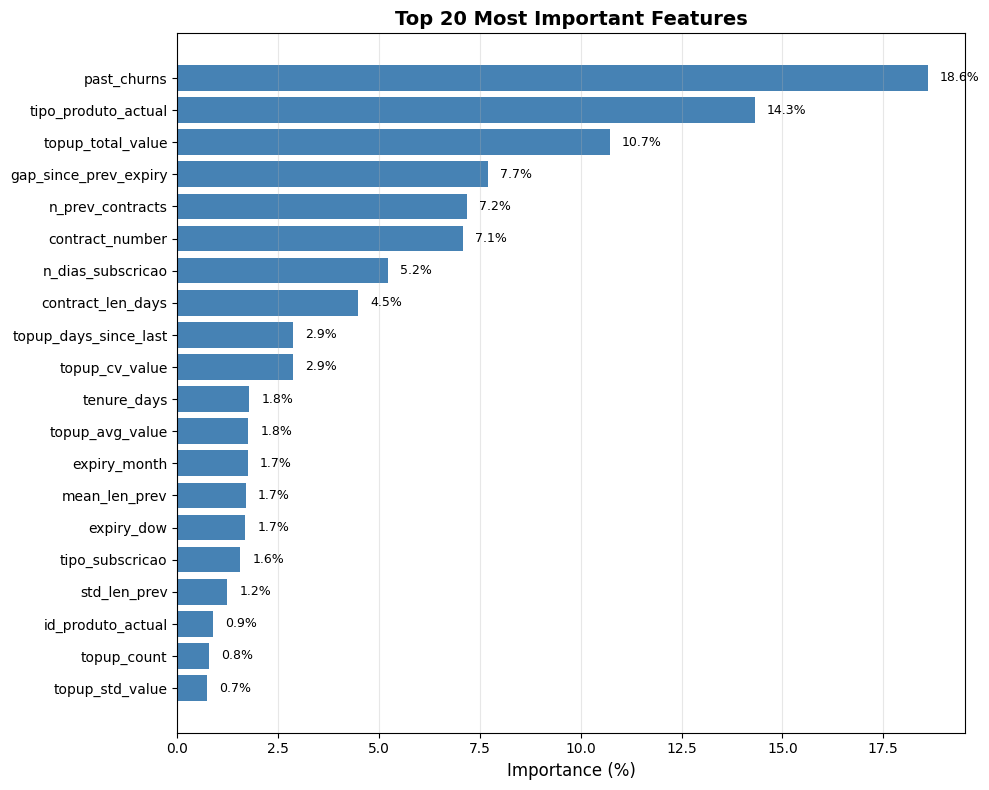


💡 How to read this chart:
   • Longer bars = more important features
   • The feature at the top is the most important
   • Numbers show what % each feature contributes


In [9]:
# Get top N features
top_features = importance_df.head(TOP_N)

# Create a horizontal bar chart
plt.figure(figsize=(10, 8))

# Create bars
plt.barh(range(len(top_features)), top_features['importance_pct'], color='steelblue')

# Add feature names on y-axis
plt.yticks(range(len(top_features)), top_features['feature'])
plt.gca().invert_yaxis()  # Highest importance at top

# Labels
plt.xlabel('Importance (%)', fontsize=12)
plt.title(f'Top {TOP_N} Most Important Features', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Add percentage labels on bars
for i, (idx, row) in enumerate(top_features.iterrows()):
    plt.text(row['importance_pct'] + 0.3, i, f"{row['importance_pct']:.1f}%", 
             va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n💡 How to read this chart:")
print("   • Longer bars = more important features")
print("   • The feature at the top is the most important")
print("   • Numbers show what % each feature contributes")

## 7. How Many Features Do We Really Need?

Let's see how many features we need to capture most of the model's power.

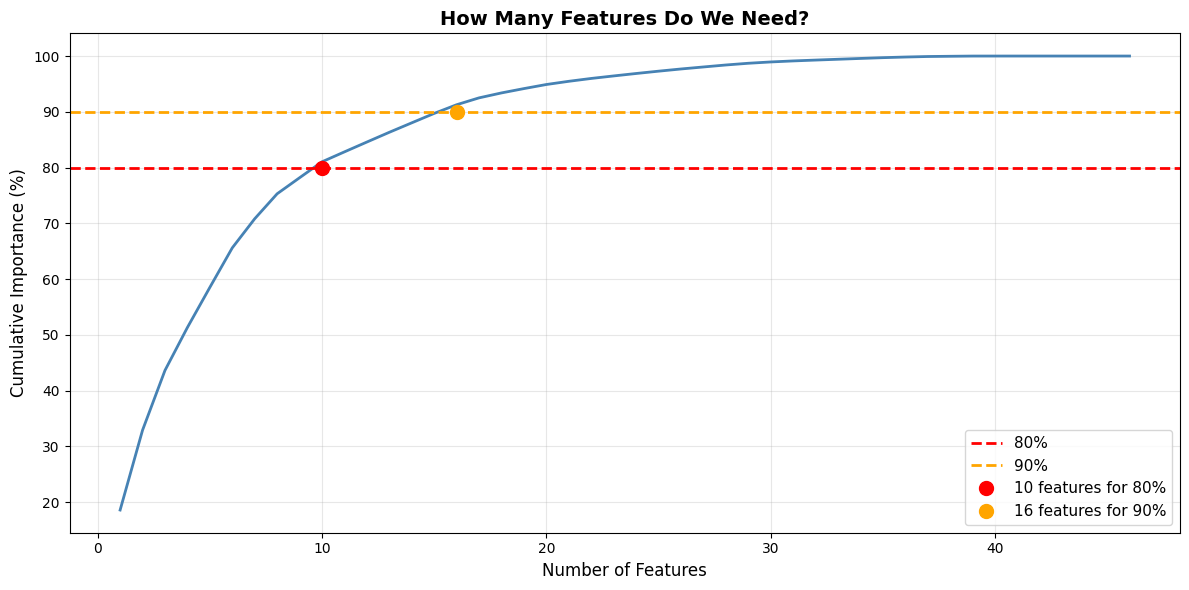


📊 Analysis:
   Total features: 46
   To get 80% of model power: 10 features
   To get 90% of model power: 16 features

💡 Insight:
   You could remove 30 features and still keep 90% of model performance!


In [10]:
# Calculate cumulative importance
importance_df['cumulative_pct'] = importance_df['importance_pct'].cumsum()

# Create line plot
plt.figure(figsize=(12, 6))

plt.plot(range(1, len(importance_df) + 1), 
         importance_df['cumulative_pct'], 
         linewidth=2, color='steelblue')

# Add reference lines
plt.axhline(y=80, color='red', linestyle='--', linewidth=2, label='80%')
plt.axhline(y=90, color='orange', linestyle='--', linewidth=2, label='90%')

# Find how many features for 80% and 90%
n_for_80 = (importance_df['cumulative_pct'] >= 80).sum()
n_for_90 = (importance_df['cumulative_pct'] >= 90).sum()

# Calculate the index (position) of when we first hit 80% and 90%
idx_80 = importance_df[importance_df['cumulative_pct'] >= 80].index[0]
idx_90 = importance_df[importance_df['cumulative_pct'] >= 90].index[0]
pos_80 = importance_df.index.get_loc(idx_80) + 1
pos_90 = importance_df.index.get_loc(idx_90) + 1

# Mark these points
plt.plot(pos_80, 80, 'ro', markersize=10, label=f'{pos_80} features for 80%')
plt.plot(pos_90, 90, 'o', color='orange', markersize=10, label=f'{pos_90} features for 90%')

plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('Cumulative Importance (%)', fontsize=12)
plt.title('How Many Features Do We Need?', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n📊 Analysis:")
print(f"   Total features: {len(importance_df)}")
print(f"   To get 80% of model power: {pos_80} features")
print(f"   To get 90% of model power: {pos_90} features")
print(f"\n💡 Insight:")
print(f"   You could remove {len(importance_df) - pos_90} features and still keep 90% of model performance!")

## 8. Remove Unimportant Features

Let's test if we can simplify the model by removing low-importance features.

**Why remove features?**
- Faster training
- Easier to understand
- Less data to collect and maintain
- Sometimes even better performance (less noise!)

In [11]:
# Define threshold: features below 0.5% importance
THRESHOLD = 0.5

# Find features below threshold
low_importance = importance_df[importance_df['importance_pct'] < THRESHOLD]
features_to_remove = low_importance['feature'].tolist()

print(f"🔍 Looking for features with < {THRESHOLD}% importance...\n")
print(f"Found {len(features_to_remove)} low-importance features:")
print(f"\n  Examples:")
for feat in features_to_remove[:10]:
    importance_val = importance_df[importance_df['feature'] == feat]['importance_pct'].iloc[0]
    print(f"    • {feat}: {importance_val:.2f}%")

if len(features_to_remove) > 10:
    print(f"    ... and {len(features_to_remove) - 10} more")

🔍 Looking for features with < 0.5% importance...

Found 24 low-importance features:

  Examples:
    • iddim_contaservico_dth: 0.45%
    • account_age_d_cliente: 0.44%
    • age: 0.42%
    • account_age_d_conta: 0.39%
    • id_contaservico: 0.36%
    • days_since_last_update_cliente: 0.36%
    • sexo: 0.31%
    • municipio: 0.24%
    • account_age_d_contaservico: 0.18%
    • days_since_last_contact: 0.15%
    ... and 14 more


## 9. Test Model Without Low-Importance Features

Let's train a new model without these features and see if performance changes.

In [12]:
if len(features_to_remove) > 0:
    print(f"Training new model without {len(features_to_remove)} low-importance features...\n")
    
    # Remove low-importance features
    X_train_reduced = X_train.drop(columns=features_to_remove)
    X_val_reduced = X_val.drop(columns=features_to_remove)
    
    # Update categorical features list
    cat_features_reduced = [f for f in cat_features if f not in features_to_remove]
    cat_indices_reduced = [X_train_reduced.columns.get_loc(col) for col in cat_features_reduced]
    
    # Create new pools
    train_pool_reduced = Pool(X_train_reduced, y_train, cat_features=cat_indices_reduced)
    val_pool_reduced = Pool(X_val_reduced, y_val, cat_features=cat_indices_reduced)
    
    # Train new model
    model_reduced = CatBoostClassifier(
        iterations=811,
        learning_rate=0.044,
        depth=5,
        l2_leaf_reg=1.015,
        random_seed=SEED,
        verbose=False
    )
    
    model_reduced.fit(train_pool_reduced, eval_set=val_pool_reduced, 
                     use_best_model=True, early_stopping_rounds=50)
    
    # Evaluate new model
    y_val_pred_reduced = model_reduced.predict_proba(val_pool_reduced)[:, 1]
    roc_auc_reduced = roc_auc_score(y_val, y_val_pred_reduced)
    
    # Compare results
    print(f"✓ New model trained!\n")
    print(f"📊 COMPARISON:\n")
    print(f"{'Metric':<25} {'Original Model':<20} {'Simplified Model'}")
    print(f"{"-" * 65}")
    print(f"{'Number of features':<25} {len(X_train.columns):<20} {len(X_train_reduced.columns)}")
    print(f"{'ROC-AUC':<25} {roc_auc:<20.4f} {roc_auc_reduced:.4f}")
    print(f"{'Difference':<25} {'':<20} {roc_auc_reduced - roc_auc:+.4f}")
    
    print(f"\n💡 Interpretation:")
    if abs(roc_auc_reduced - roc_auc) < 0.005:
        print(f"   ✓ Performance is basically the same!")
        print(f"   ✓ You can safely remove {len(features_to_remove)} features")
        print(f"   ✓ Model is now simpler and faster")
    elif roc_auc_reduced > roc_auc:
        print(f"   ✓ Performance actually IMPROVED!")
        print(f"   ✓ Those features were just adding noise")
    else:
        print(f"   ⚠️ Performance dropped a bit")
        print(f"   💡 Consider using a lower threshold (remove fewer features)")
else:
    print(f"\n💡 All features have importance above {THRESHOLD}%")
    print(f"   Try a higher threshold if you want to simplify the model.")

Training new model without 24 low-importance features...

✓ New model trained!

📊 COMPARISON:

Metric                    Original Model       Simplified Model
-----------------------------------------------------------------
Number of features        46                   22
ROC-AUC                   0.7713               0.7724
Difference                                     +0.0010

💡 Interpretation:
   ✓ Performance is basically the same!
   ✓ You can safely remove 24 features
   ✓ Model is now simpler and faster


## 10. SHAP Values - Explain Individual Predictions

**What is SHAP?**
- SHAP (SHapley Additive exPlanations) = A way to explain WHY the model made a specific prediction
- Shows HOW MUCH each feature contributed to ONE prediction
- Like a detailed receipt showing what you paid for!

**Difference from regular feature importance:**
- Feature importance = Which features are important OVERALL (across all predictions)
- SHAP = Which features mattered for THIS specific customer

**Example:**
```
Feature Importance says: "Usage is the most important feature overall"
SHAP says: "For customer #42, low usage increased churn risk by 15%"
```

In [13]:
print("Computing SHAP values (this takes a minute)...\n")

# We'll use a SAMPLE of data to make it faster
# (SHAP can be slow on large datasets)
sample_size = 1000
X_val_sample = X_val.sample(n=sample_size, random_state=SEED)
y_val_sample = y_val.loc[X_val_sample.index]

# Create SHAP explainer for tree models
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_val_sample)

# If binary classification, we get a list - take the positive class
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # Positive class (churn = 1)

print(f"✓ SHAP values computed for {sample_size} customers")

Computing SHAP values (this takes a minute)...

✓ SHAP values computed for 1000 customers


### What is a SHAP Value?

**Simple explanation:**
- A SHAP value is a NUMBER that tells you how much a feature pushed the prediction up or down
- Positive SHAP value = feature increases the prediction (higher churn risk)
- Negative SHAP value = feature decreases the prediction (lower churn risk)
- The bigger the number, the bigger the impact

**Example:**
```
Base prediction (average): 40% churn risk
Customer #42:
  • past_churns = 5      → SHAP = +0.15  (adds 15% to prediction)
  • contract_number = 44 → SHAP = -0.20  (subtracts 20% from prediction)
  • usage = 100          → SHAP = -0.10  (subtracts 10% from prediction)
  
Final prediction: 40% + 15% - 20% - 10% = 25% churn risk
```

**Key insight:** SHAP values add up to explain the full prediction!

### SHAP Summary Plot

This plot shows which features are most important AND how their values affect predictions.

/var/folders/3d/dh5fxyvd55sbf5r8pv3bfclw0000gq/T/ipykernel_31553/1701712072.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_val_sample, max_display=TOP_N, show=False)


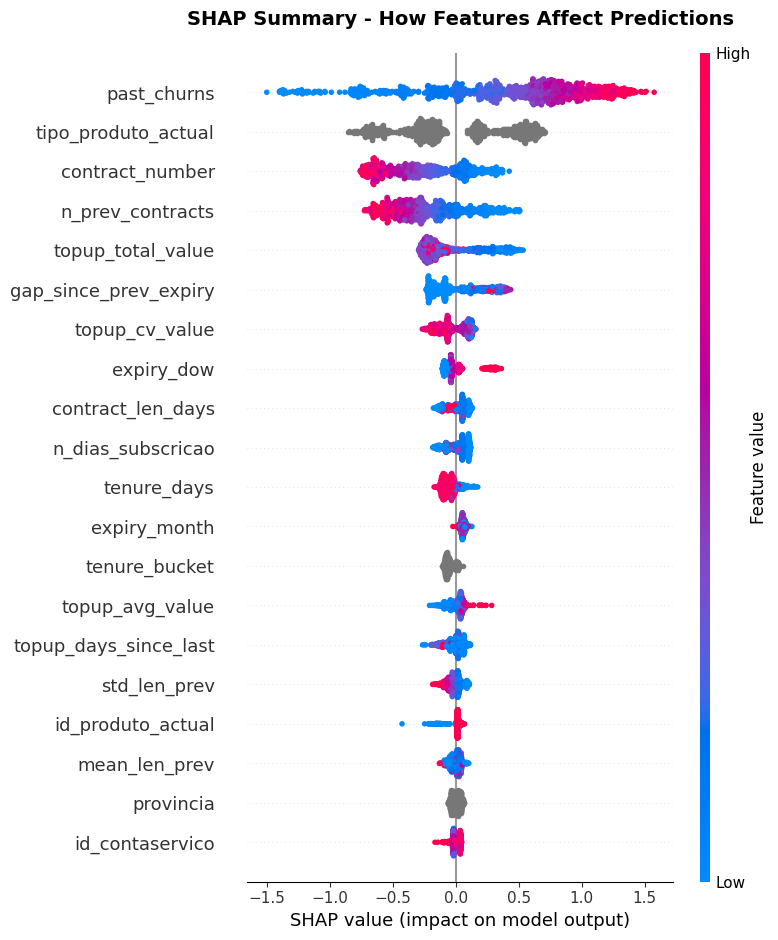


💡 How to read this plot:
   • Each DOT is one customer
   • Features at TOP are most important
   • X-axis: How much the feature pushes prediction
     - Right (positive) = Increases churn risk
     - Left (negative) = Decreases churn risk
   • Color: Feature value
     - Red = High value
     - Blue = Low value

   Example: If you see BLUE dots on the RIGHT for 'usage'
   → Low usage (blue) increases churn risk (right)


In [24]:
# Create SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val_sample, max_display=TOP_N, show=False)
plt.title('SHAP Summary - How Features Affect Predictions', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n💡 How to read this plot:")
print("   • Each DOT is one customer")
print("   • Features at TOP are most important")
print("   • X-axis: How much the feature pushes prediction")
print("     - Right (positive) = Increases churn risk")
print("     - Left (negative) = Decreases churn risk")
print("   • Color: Feature value")
print("     - Red = High value")
print("     - Blue = Low value")
print("\n   Example: If you see BLUE dots on the RIGHT for 'usage'")
print("   → Low usage (blue) increases churn risk (right)")

### Explain One Customer's Prediction

Let's pick one customer and see exactly WHY the model predicted they would churn.

In [30]:
# Pick a customer (let's use customer at index 42)
customer_idx = 4
customer_data = X_val_sample.iloc[customer_idx]
customer_shap = shap_values[customer_idx]
customer_actual = y_val_sample.iloc[customer_idx]

# Get the model's prediction for this customer
customer_pred_proba = model.predict_proba(customer_data.values.reshape(1, -1))[0, 1]

print("="*70)
print(f"🔍 EXPLAINING PREDICTION FOR CUSTOMER #{customer_idx}")
print("="*70)

print(f"\n📊 Prediction:")
print(f"   Churn probability: {customer_pred_proba:.1%}")
print(f"   Actual outcome: {'CHURNED' if customer_actual == 1 else 'STAYED'}")

# Get top features that pushed the prediction
# Positive SHAP = increases churn risk
# Negative SHAP = decreases churn risk
feature_contributions = pd.DataFrame({
    'feature': X_train.columns,
    'value': customer_data.values,
    'shap_value': customer_shap
})

# Sort by absolute SHAP value to get most impactful features
feature_contributions['abs_shap'] = feature_contributions['shap_value'].abs()
feature_contributions = feature_contributions.sort_values('abs_shap', ascending=False)

print(f"\n🎯 Top 10 Reasons for This Prediction:\n")
for i, (idx, row) in enumerate(feature_contributions.head(10).iterrows(), 1):
    direction = "INCREASES" if row['shap_value'] > 0 else "DECREASES"
    arrow = "↑" if row['shap_value'] > 0 else "↓"
    print(f"   {i}. {row['feature']} = {row['value']}")
    print(f"      {arrow} {direction} churn risk by {abs(row['shap_value']):.3f}\n")

print("="*70)

🔍 EXPLAINING PREDICTION FOR CUSTOMER #4

📊 Prediction:
   Churn probability: 32.0%
   Actual outcome: STAYED

🎯 Top 10 Reasons for This Prediction:

   1. past_churns = 12
      ↑ INCREASES churn risk by 0.773

   2. contract_number = 48
      ↓ DECREASES churn risk by 0.627

   3. tipo_produto_actual = normal
      ↑ INCREASES churn risk by 0.582

   4. n_prev_contracts = 48
      ↓ DECREASES churn risk by 0.468

   5. topup_total_value = 14736.84
      ↓ DECREASES churn risk by 0.277

   6. gap_since_prev_expiry = 1.0
      ↓ DECREASES churn risk by 0.112

   7. tenure_days = 474
      ↓ DECREASES churn risk by 0.104

   8. contract_len_days = 2
      ↑ INCREASES churn risk by 0.094

   9. n_dias_subscricao = 3
      ↑ INCREASES churn risk by 0.093

   10. expiry_dow = 0
      ↓ DECREASES churn risk by 0.092



### SHAP Waterfall Plot

This shows how we go from the average prediction to THIS customer's prediction, step by step.

📊 Waterfall Plot - How Features Combine to Make the Prediction:



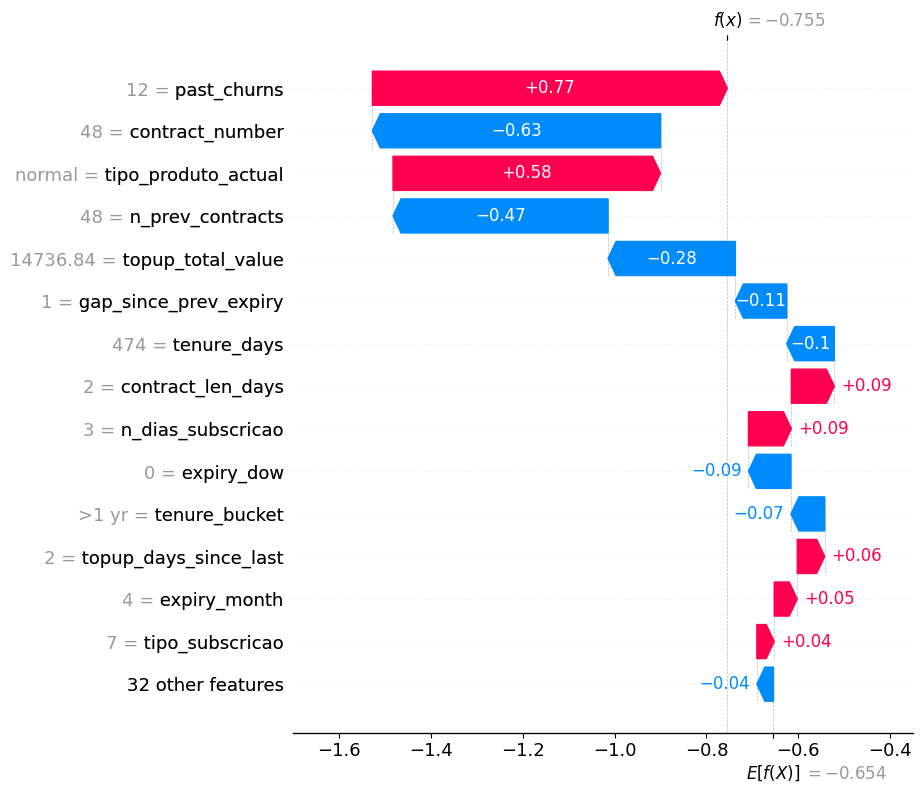


💡 How to read this waterfall:
   • Starts at the AVERAGE prediction (base value)
   • Each bar shows one feature pushing prediction UP or DOWN
   • Red = pushes UP (increases churn risk)
   • Blue = pushes DOWN (decreases churn risk)
   • Final value = actual prediction for this customer


In [31]:
# Create waterfall plot
print("📊 Waterfall Plot - How Features Combine to Make the Prediction:\n")

shap.waterfall_plot(
    shap.Explanation(
        values=customer_shap,
        base_values=explainer.expected_value,
        data=customer_data.values,
        feature_names=X_train.columns.tolist()
    ),
    max_display=15,
    show=True
)

print("\n💡 How to read this waterfall:")
print("   • Starts at the AVERAGE prediction (base value)")
print("   • Each bar shows one feature pushing prediction UP or DOWN")
print("   • Red = pushes UP (increases churn risk)")
print("   • Blue = pushes DOWN (decreases churn risk)")
print("   • Final value = actual prediction for this customer")

## 11. Summary: Which Features Matter Most?

Let's create a final summary of what we learned.

In [17]:
print("="*70)
print("📋 FEATURE IMPORTANCE SUMMARY")
print("="*70)

print(f"\n🏆 TOP 5 MOST IMPORTANT FEATURES:\n")
for i, (idx, row) in enumerate(importance_df.head(5).iterrows(), 1):
    print(f"   {i}. {row['feature']}")
    print(f"      → Contributes {row['importance_pct']:.1f}% to predictions\n")

print(f"📊 KEY INSIGHTS:\n")
print(f"   • Total features: {len(importance_df)}")
print(f"   • Top 10 features explain: {top_10_pct:.1f}% of predictions")
print(f"   • Features needed for 90% power: {pos_90}")
print(f"   • Potentially removable features: {len(features_to_remove)} (< {THRESHOLD}% importance)")

print(f"\n💡 RECOMMENDATIONS:\n")
print(f"   1. Focus on collecting/maintaining the top {pos_90} features")
print(f"   2. Investigate why the top feature is so important")
print(f"   3. Consider removing the {len(features_to_remove)} low-importance features")
print(f"   4. Use this analysis to explain the model to stakeholders")

print("\n" + "="*70)

📋 FEATURE IMPORTANCE SUMMARY

🏆 TOP 5 MOST IMPORTANT FEATURES:

   1. past_churns
      → Contributes 18.6% to predictions

   2. tipo_produto_actual
      → Contributes 14.3% to predictions

   3. topup_total_value
      → Contributes 10.7% to predictions

   4. gap_since_prev_expiry
      → Contributes 7.7% to predictions

   5. n_prev_contracts
      → Contributes 7.2% to predictions

📊 KEY INSIGHTS:

   • Total features: 46
   • Top 10 features explain: 81.0% of predictions
   • Features needed for 90% power: 16
   • Potentially removable features: 24 (< 0.5% importance)

💡 RECOMMENDATIONS:

   1. Focus on collecting/maintaining the top 16 features
   2. Investigate why the top feature is so important
   3. Consider removing the 24 low-importance features
   4. Use this analysis to explain the model to stakeholders



---
## 🎓 Key Takeaways

### What is Feature Importance?
- A score showing how much each feature contributes to predictions
- Expressed as a percentage (easier to understand)
- Higher = more important

### Why Does It Matter?
1. **Understand your model** - Know what drives predictions
2. **Simplify** - Remove features that don't help
3. **Explain** - Tell others why the model makes certain predictions
4. **Debug** - Find if model is using weird features

### What We Learned:
- ✓ How to extract feature importance from CatBoost
- ✓ How to visualize it with bar charts
- ✓ How to find the minimum set of features needed
- ✓ How to test model performance after removing features

### Common Patterns:
- **Usually: Few features do most of the work**
  - Example: 20 features might explain 90% of predictions
  - The other 30 features only add 10%!

- **Removing low-importance features often helps:**
  - Faster training
  - Less overfitting
  - Easier to understand and maintain

### ⚠️ Watch Out For:
1. **A feature that's TOO important** (like 50%+)
   - Might be data leakage!
   - Example: Using "churned_last_month" to predict "will_churn_this_month"

2. **Unexpected important features**
   - If "customer_shoe_size" is important for churn... something's wrong!
   - Investigate why

3. **Don't remove features without testing**
   - Always check if performance stays the same
   - Use validation or cross-validation

## 🚀 Next Steps

1. **Document your top features** - Write down what they mean for your team
2. **Share with stakeholders** - Show them what drives predictions
3. **Monitor in production** - Track if important features change over time
4. **Use for feature engineering** - Create new features similar to important ones

## 📖 Real-World Example:

```
Business Question: "Why is this customer predicted to churn?"

Your Answer (using feature importance):
"The model predicts 85% churn risk because:
 1. Usage dropped 60% last month (most important factor)
 2. Customer called support 5 times (second most important)
 3. Account is 3+ years old (third most important)"

Action: Stakeholders can now design targeted retention campaigns!
```